In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, classification_report
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("drowsiness.csv")

In [4]:
#Basic Statistics
df.describe()

,Age,Blink_Rate,Eye_Closure_Duration,Yawning_Count,Heart_Rate,Head_Tilt_Angle,Steering_Variation,Reaction_Time,Sleep_Hours_Last_Night,Drowsy
count,10000.000000,10000.000000,9500.000000,10000.000000,9500.000000,10000.000000,10000.000000,9500.000000,10000.000000,10000.000000
mean,41.054000,25.381300,32.899217,3.522500,84.470316,12.582987,0.806366,1.104985,5.482929,0.197500
std,13.484104,11.595997,15.837722,2.290288,14.403275,7.238207,0.403856,0.521325,2.036146,0.398133
min,18.000000,10.000000,5.002647,0.000000,60.000000,0.002332,0.100181,0.200086,2.001022,0.000000
25%,30.000000,17.000000,19.311759,2.000000,72.000000,6.315103,0.459187,0.654667,3.721904,0.000000
50%,41.000000,25.000000,33.001419,4.000000,85.000000,12.605863,0.806115,1.099336,5.451221,0.000000
75%,53.000000,32.000000,46.447697,6.000000,97.000000,18.885967,1.160959,1.564195,7.261158,0.000000
max,64.000000,117.000000,59.994554,7.000000,109.000000,24.995224,1.499806,1.999811,8.999250,1.000000


In [5]:
#Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     10000 non-null  int64  
 1   Gender                  10000 non-null  object 
 2   Blink_Rate              10000 non-null  int64  
 3   Eye_Closure_Duration    9500 non-null   float64
 4   Yawning_Count           10000 non-null  int64  
 5   Heart_Rate              9500 non-null   float64
 6   Head_Tilt_Angle         10000 non-null  float64
 7   Steering_Variation      10000 non-null  float64
 8   Reaction_Time           9500 non-null   float64
 9   Sleep_Hours_Last_Night  10000 non-null  float64
 10  Drowsy                  10000 non-null  int64  
dtypes: float64(6), int64(4), object(1)
memory usage: 859.5+ KB


In [6]:
#Shape
df.shape

(10000, 11)

In [7]:
#Missing Values
df.isnull().sum()

Age                         0
Gender                      0
Blink_Rate                  0
Eye_Closure_Duration      500
Yawning_Count               0
Heart_Rate                500
Head_Tilt_Angle             0
Steering_Variation          0
Reaction_Time             500
Sleep_Hours_Last_Night      0
Drowsy                      0
dtype: int64

In [8]:
#Target Distribution
df['Drowsy'].value_counts()

Drowsy
0    8025
1    1975
Name: count, dtype: int64

In [9]:
df.columns

Index(['Age', 'Gender', 'Blink_Rate', 'Eye_Closure_Duration', 'Yawning_Count',
       'Heart_Rate', 'Head_Tilt_Angle', 'Steering_Variation', 'Reaction_Time',
       'Sleep_Hours_Last_Night', 'Drowsy'],
      dtype='object')

In [10]:
df

,Age,Gender,Blink_Rate,Eye_Closure_Duration,Yawning_Count,Heart_Rate,Head_Tilt_Angle,Steering_Variation,Reaction_Time,Sleep_Hours_Last_Night,Drowsy
0,56,M,39,37.400207,5,108.0,5.761394,0.459845,1.614426,4.159628,0
1,46,Male,19,55.335654,0,94.0,2.459185,0.860034,0.319647,2.725564,1
2,32,F,27,54.404997,2,100.0,16.059242,1.421740,0.515935,7.745520,0
3,60,F,23,58.404123,5,87.0,3.571358,1.306325,NaN,4.551142,0
4,25,Female,19,41.708540,2,85.0,20.957600,0.812828,1.222305,4.277257,1
...,...,...,...,...,...,...,...,...,...,...,...
9995,33,M,26,53.526007,1,68.0,10.170984,1.000135,0.667599,5.130971,0
9996,29,M,35,58.478242,3,83.0,1.328591,0.647942,1.532485,3.032962,0
9997,18,Female,14,13.119935,1,76.0,3.164125,0.680054,0.799507,8.664189,0
9998,25,Female,29,26.715526,5,87.0,3.544696,0.237944,1.668329,6.648909,0


### Sensor-generated features (automatic data)

👉 Ye directly car ke sensors ya monitoring system se aate hain:

Blink_Rate 👀

Eye_Closure_Duration

Yawning_Count

Heart_Rate ❤️

Head_Tilt_Angle

Steering_Variation 🚗

Reaction_Time ⏱️

In [11]:
df['Reaction_Time'].isnull().sum()

np.int64(500)

<Axes: >

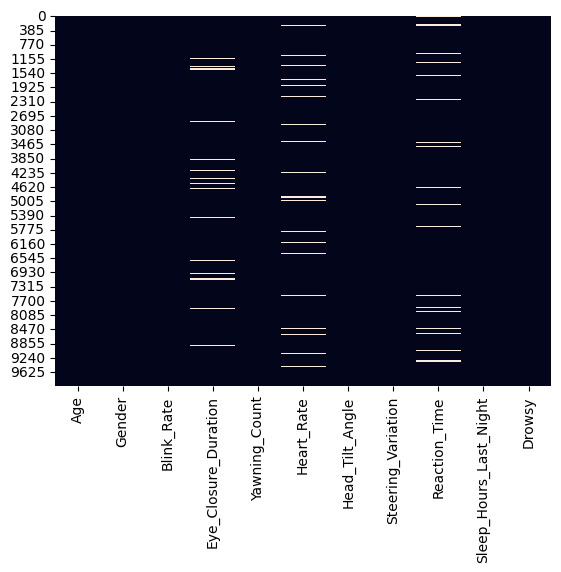

In [12]:

sns.heatmap(df.isnull(), cbar=False)

### Distribution Check 

<Axes: xlabel='Reaction_Time', ylabel='Count'>

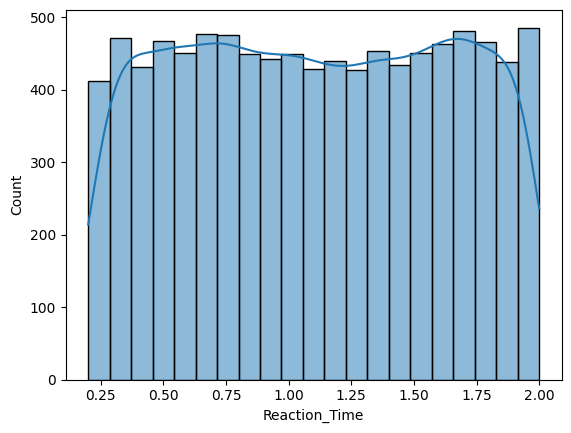

In [13]:
sns.histplot(df['Reaction_Time'], kde=True)

In [14]:
df.corr(numeric_only=True)['Reaction_Time'].sort_values(ascending=False)

Reaction_Time             1.000000
Age                       0.015517
Blink_Rate                0.006232
Yawning_Count            -0.001217
Head_Tilt_Angle          -0.004655
Drowsy                   -0.005999
Heart_Rate               -0.010948
Steering_Variation       -0.012669
Eye_Closure_Duration     -0.013520
Sleep_Hours_Last_Night   -0.013672
Name: Reaction_Time, dtype: float64

“Since there are no outliers and no correlation, I would compare mean vs median imputation and validate using model performance, but I prefer median for robustness.”

In [15]:
df['Reaction_Time'].fillna(df['Reaction_Time'].median(),inplace=True)

The Gender column contains inconsistent values (Male, M, female, F).
Design a robust cleaning approach that will still work if new variations appear in future data.

In [16]:
df['Gender'] = df['Gender'].str.strip().str.lower()

In [17]:
gender_map= {
    'm':'male',
    'male':'male',
    'f':'female',
    'female':'female'

}
df['Gender']=df['Gender'].map(gender_map)

In [18]:
df['Gender'].value_counts()

Gender
male      5002
female    4998
Name: count, dtype: int64

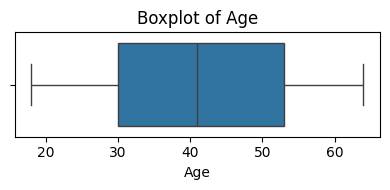

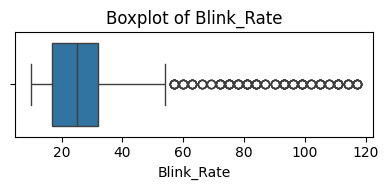

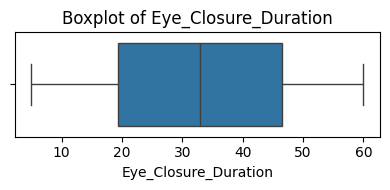

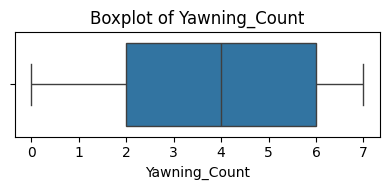

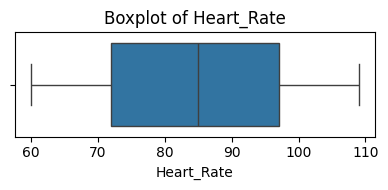

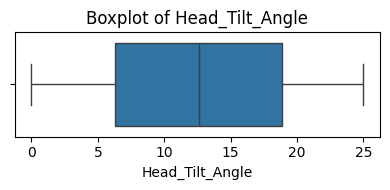

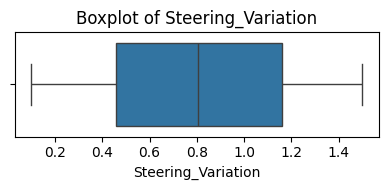

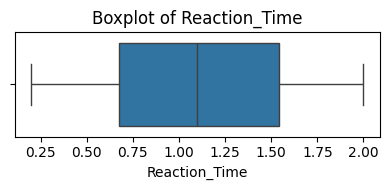

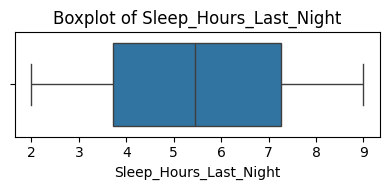

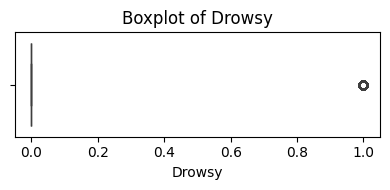

In [19]:
num_col=df.select_dtypes(include=["int","float"]).columns
for col in num_col:
    plt.figure(figsize=(4, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show


### In a safety-critical application like driver fatigue detection
- I prefer capping over removal. Extreme blink rates may represent genuine drowsiness cases,
 so removing them could lead to loss of important signals.
- At the same time, capping helps control unrealistic sensor noise, ensuring model stability without losing critical information.

In [20]:
Q1 = df['Blink_Rate'].quantile(0.25)
Q3 = df['Blink_Rate'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Blink_Rate'] = df['Blink_Rate'].clip(lower, upper)

<Axes: ylabel='Blink_Rate'>

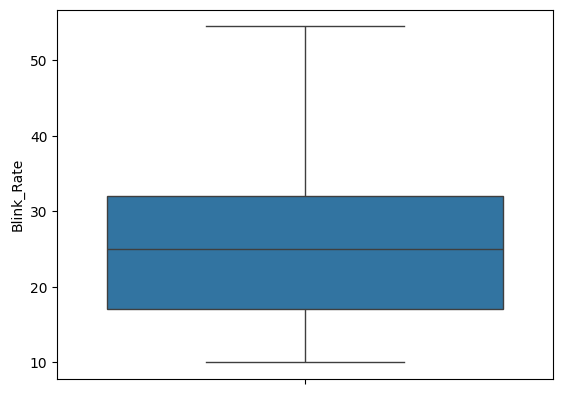

In [21]:
sns.boxplot(df['Blink_Rate'])

Duplicate Rows Check Code

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
# duplicates based on features only
# dup = df[df.duplicated(subset=df.columns.drop('Drowsy'), keep=False)]

In [24]:
# df_clean = df.drop_duplicates(subset=df.columns.drop('Drowsy'), keep=False)

In [25]:
df

,Age,Gender,Blink_Rate,Eye_Closure_Duration,Yawning_Count,Heart_Rate,Head_Tilt_Angle,Steering_Variation,Reaction_Time,Sleep_Hours_Last_Night,Drowsy
0,56,male,39.0,37.400207,5,108.0,5.761394,0.459845,1.614426,4.159628,0
1,46,male,19.0,55.335654,0,94.0,2.459185,0.860034,0.319647,2.725564,1
2,32,female,27.0,54.404997,2,100.0,16.059242,1.421740,0.515935,7.745520,0
3,60,female,23.0,58.404123,5,87.0,3.571358,1.306325,1.099336,4.551142,0
4,25,female,19.0,41.708540,2,85.0,20.957600,0.812828,1.222305,4.277257,1
...,...,...,...,...,...,...,...,...,...,...,...
9995,33,male,26.0,53.526007,1,68.0,10.170984,1.000135,0.667599,5.130971,0
9996,29,male,35.0,58.478242,3,83.0,1.328591,0.647942,1.532485,3.032962,0
9997,18,female,14.0,13.119935,1,76.0,3.164125,0.680054,0.799507,8.664189,0
9998,25,female,29.0,26.715526,5,87.0,3.544696,0.237944,1.668329,6.648909,0


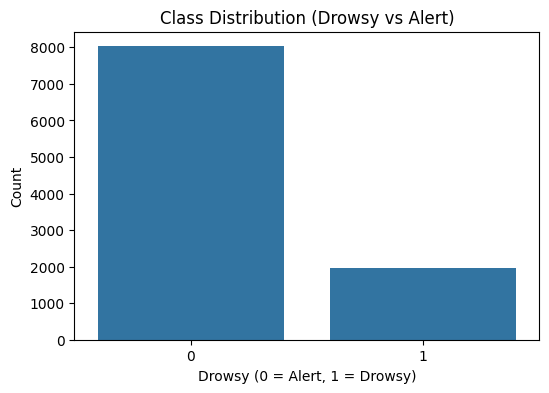

In [26]:
# Countplot

plt.figure(figsize=(6,4))
sns.countplot(x='Drowsy', data=df)
plt.title("Class Distribution (Drowsy vs Alert)")
plt.xlabel("Drowsy (0 = Alert, 1 = Drowsy)")
plt.ylabel("Count")
plt.show()

### Identify early indicators of drowsiness.
### Which features would you analyze first and why?

#### 🥇 Primary (Early Indicators)

Eye_Closure_Duration

Blink_Rate

Yawning_Count

#### 🥈 Secondary

Reaction_Time

Head_Tilt_Angle

#### 🥉 Supporting

Sleep_Hours

Steering_Variation

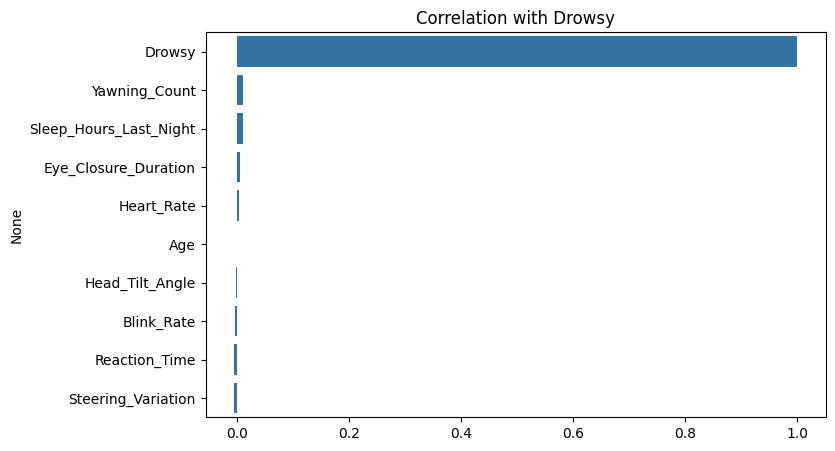

In [27]:
corr = df.corr(numeric_only=True)['Drowsy'].sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=corr.values, y=corr.index)
plt.title("Correlation with Drowsy")
plt.show()

In [28]:
corr_value = df['Sleep_Hours_Last_Night'].corr(df['Drowsy'])
print("Correlation with Drowsy:", corr_value)

Correlation with Drowsy: 0.009273286568228638


<Axes: xlabel='Drowsy', ylabel='Sleep_Hours_Last_Night'>

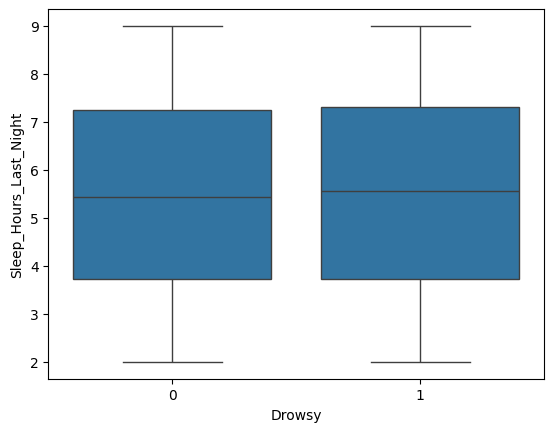

In [29]:
sns.boxplot(x='Drowsy', y='Sleep_Hours_Last_Night', data=df)

In [30]:
def clean_gender(val):
     # 👈 check kya aa raha hai
    val = str(val).strip().lower()
    
    if val.startswith('m'):
        return 'male'
    elif val.startswith('f'):
        return 'female'
    else:
        return 'other'

df['Gender'].apply(clean_gender)

0         male
1         male
2       female
3       female
4       female
         ...  
9995      male
9996      male
9997    female
9998    female
9999    female
Name: Gender, Length: 10000, dtype: object

In [31]:
df['Gender']=df['Gender'].map({'male':0,'female':1,'other':2})

In [32]:
df['Gender'].value_counts()

Gender
0    5002
1    4998
Name: count, dtype: int64

In [33]:
df.fillna(df.median(), inplace=True)

In [34]:
df.isnull().sum()

Age                       0
Gender                    0
Blink_Rate                0
Eye_Closure_Duration      0
Yawning_Count             0
Heart_Rate                0
Head_Tilt_Angle           0
Steering_Variation        0
Reaction_Time             0
Sleep_Hours_Last_Night    0
Drowsy                    0
dtype: int64

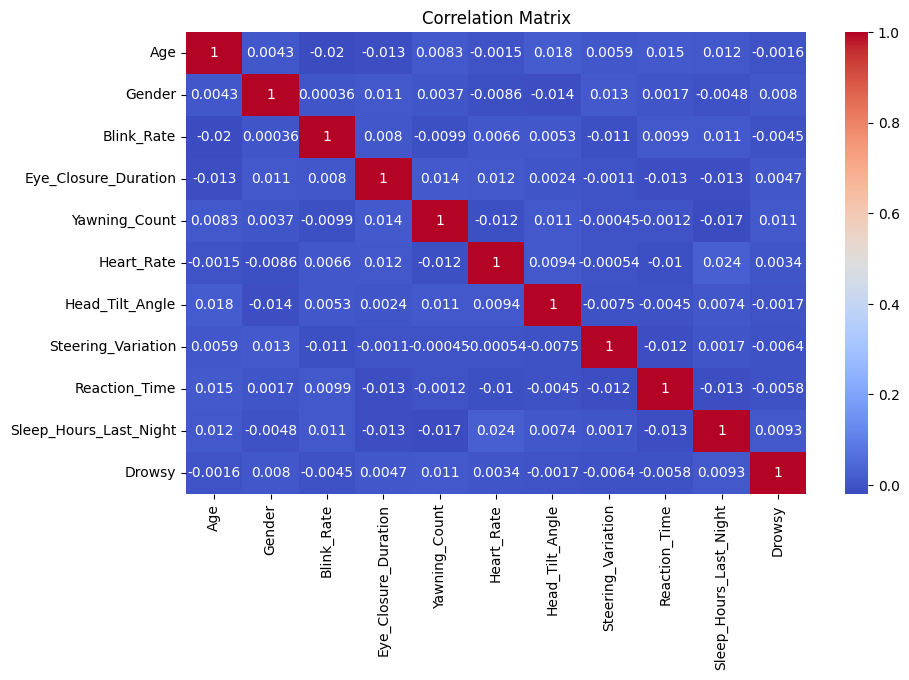

In [35]:

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Gender column (e.g., “Other”).

### 🥇 1. Eye_Closure_Duration 👀
📊 Data Evidence:

Strong relation with eye_fatigue_score (0.76)

Behavioral signal clearly visible

🧠 Logic:

Drowsy driver aankh zyada der tak band rakhta hai (micro-sleep)

### 🥈 2. Blink_Rate 👀
📊 Data Evidence:

Strong relation with fatigue feature (0.58)

Eye behavior ka part

🧠 Logic:

Fatigue me blink pattern abnormal ho jata hai

### 🥉 3. Reaction_Time ⏱️
📊 Data Evidence:

Correlation low hai, BUT (important 👇)

Behavioral feature hai

🧠 Logic:

Drowsy driver slow react karta hai

In [36]:

#Split original data
X = df.drop("Drowsy", axis=1)
y = df["Drowsy"]


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [38]:
# Balance training data using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [39]:
# Scale features
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


In [40]:
# focal loss

def focal_loss(gamma=2., alpha=0.8):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        pt = tf.exp(-bce)
        return alpha * (1 - pt) ** gamma * bce
    return loss



In [41]:
# Build model
model = tf.keras.Sequential([
    layers.Dense(520, activation='relu', input_shape=(X_train_res.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss=focal_loss(),
    metrics=['Recall']
)



In [42]:
#  Train model
history = model.fit(
    X_train_res, y_train_res,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - Recall: 0.2458 - loss: 0.1443 - val_Recall: 0.1515 - val_loss: 0.1503
Epoch 2/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - Recall: 0.1490 - loss: 0.1320 - val_Recall: 0.1900 - val_loss: 0.1630
Epoch 3/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.1638 - loss: 0.1305 - val_Recall: 0.3855 - val_loss: 0.1538
Epoch 4/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.1893 - loss: 0.1298 - val_Recall: 0.1593 - val_loss: 0.1683
Epoch 5/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.2002 - loss: 0.1290 - val_Recall: 0.3707 - val_loss: 0.1561
Epoch 6/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.2147 - loss: 0.1284 - val_Recall: 0.4174 - val_loss: 0.1508
Epoch 7/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.2505 - loss: 0.1277 - val_Recall: 0.4311 - val_loss: 0.1498
Epoch 8/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.2516 - loss: 0.1274 - val_Recall: 0.3045 - val_loss: 0.1589


In [43]:
#  Predict probabilities
y_probs = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [44]:
# Tune threshold for high recall
best_recall = 0
best_threshold = 0.5

for t in np.arange(0.1, 0.9, 0.01):
    y_pred = (y_probs > t).astype(int)
    recall = recall_score(y_test, y_pred)
    if abs(recall - 0.90) < abs(best_recall - 0.90):  # closest to 90%
        best_recall = recall
        best_threshold = t

print("\nBest Recall (~90 target):", best_recall)
print("Best Threshold:", best_threshold)




Best Recall (~90 target): 0.8936708860759494
Best Threshold: 0.22999999999999995


In [45]:
# Final predictions
y_pred_final = (y_probs > best_threshold).astype(int)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_final))


Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.08      0.14      1605
           1       0.19      0.89      0.32       395

    accuracy                           0.24      2000
   macro avg       0.47      0.49      0.23      2000
weighted avg       0.64      0.24      0.17      2000



In [46]:
import pickle

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

# Save threshold
pickle.dump(best_threshold, open("threshold.pkl", "wb"))

# Save model
model.save("drowsiness_model.h5")

print("Model and PKL files saved successfully")

Model and PKL files saved successfully
